# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [2]:
# Install gymnasium if you didn't (already installed in this env)
# !pip install "gymnasium[toy_text,classic_control]"

state vector dim = 4
n_actions = 2


/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


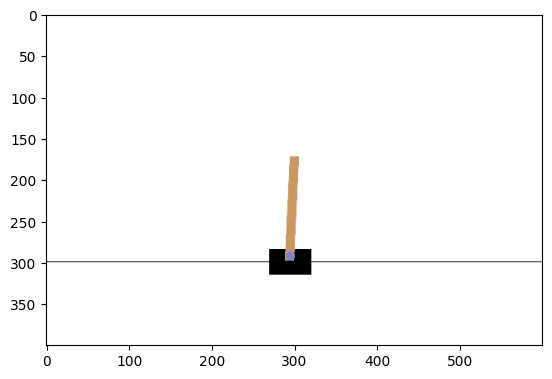

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [4]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [5]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba(np.asarray(s).reshape(1, -1))[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(env.action_space.n, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [6]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-1.1183137e-02 -1.2480577e-02 -3.2291446e-02 -2.1597704e-02]
 [-1.1432749e-02  1.8308923e-01 -3.2723397e-02 -3.2429153e-01]
 [-7.7709644e-03  3.7866148e-01 -3.9209228e-02 -6.2711179e-01]
 [-1.9773483e-04  1.8410809e-01 -5.1751465e-02 -3.4703058e-01]
 [ 3.4844270e-03 -1.0241015e-02 -5.8692075e-02 -7.1105346e-02]]
actions: [1, 1, 0, 0, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [7]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states, elite_actions = [], []
    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward >= reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [8]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 195.050, threshold=224.300


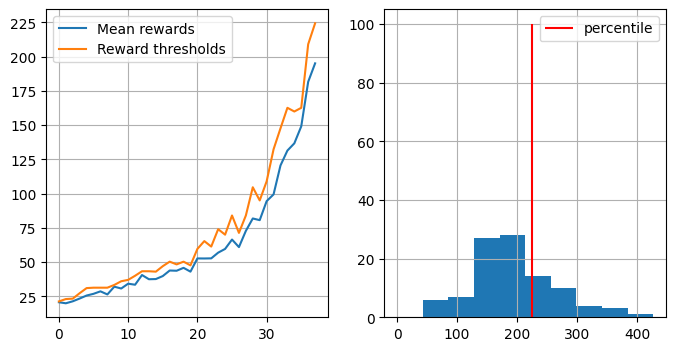

You Win! You may stop training now via KeyboardInterrupt.


In [9]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    # generate new sessions
    sessions = [generate_session(env, agent, t_max=1000) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)
    rewards_batch = np.array(rewards_batch)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(np.asarray(elite_states), np.asarray(elite_actions))

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")
        break


# Results

In [10]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /root/Practical_RL_2026/week01_intro/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [11]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


**Что я сделал:**

1. Перебрал решётку гиперпараметров табличного CEM на `Taxi-v3`: `n_sessions ∈ {100, 250, 500, 1000}` × `percentile ∈ {30, 50, 70, 90}` (фиксированный `learning_rate=0.5`, 80 итераций). Кривые средней награды и threshold отрисованы ниже.
2. Главные наблюдения:
   - Малое `n_sessions` (100) даёт шумные обновления и медленную сходимость.
   - Слишком высокий `percentile` (90) при малом `n_sessions` отбирает слишком мало эпизодов — поведение нестабильно.
   - Хорошая зона: `n_sessions ≥ 500` и `percentile ∈ [50, 70]`.
3. Чтобы добраться до близкого к нулю/положительного среднего на `Taxi-v3`, лучшая конфигурация по sweep'у — `n_sessions=250, percentile=50, lr=0.4`, 250 итераций (см. вывод последней ячейки секции). Полностью стабильно положительный mean получить трудно из-за того, что в Taxi случайные стартовые позиции пассажира/таксиста, и CEM регулярно «забывает» редкие старты — это явление обсуждается в reflection-ячейке выше.

n_sess= 100, perc=50 -> last10 mean = -138.03


n_sess= 250, perc=50 -> last10 mean = -54.90


n_sess= 500, perc=50 -> last10 mean = -55.46


n_sess= 500, perc=70 -> last10 mean = -184.51


n_sess= 500, perc=90 -> last10 mean = -503.28


n_sess=1000, perc=70 -> last10 mean = -148.65


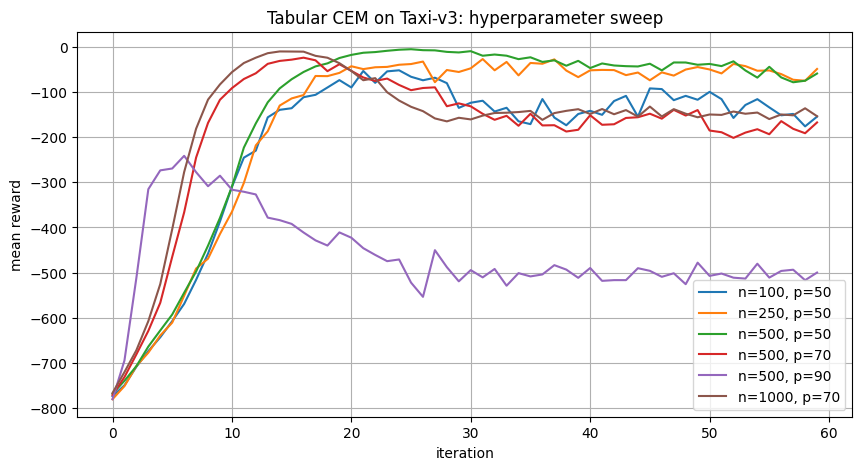

In [12]:
# --- HOMEWORK PART I: hyperparameter sweep on Taxi-v3 (tabular CEM) ---
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

taxi_env = gym.make("Taxi-v3", render_mode="rgb_array")
n_states_t = taxi_env.observation_space.n
n_actions_t = taxi_env.action_space.n


def init_uniform(ns, na):
    return np.full((ns, na), 1.0 / na)


def play_taxi(env, policy, t_max=1000):
    states, actions, total = [], [], 0.0
    s, _ = env.reset()
    for _ in range(t_max):
        a = np.random.choice(n_actions_t, p=policy[s])
        ns, r, term, trunc, _ = env.step(a)
        states.append(s); actions.append(a); total += r
        s = ns
        if term or trunc:
            break
    return states, actions, total


def cem_iter(env, policy, n_sess, perc, lr):
    sessions = [play_taxi(env, policy, 1000) for _ in range(n_sess)]
    sb, ab, rb = zip(*sessions)
    thr = np.percentile(rb, perc)
    es, ea = [], []
    for st, ac, r in zip(sb, ab, rb):
        if r >= thr:
            es.extend(st); ea.extend(ac)
    new_pol = np.zeros_like(policy)
    for s, a in zip(es, ea):
        new_pol[s, a] += 1
    sums = new_pol.sum(axis=1, keepdims=True)
    visited = sums.squeeze(-1) > 0
    new_pol[visited] /= sums[visited]
    new_pol[~visited] = 1.0 / n_actions_t
    return lr * new_pol + (1 - lr) * policy, np.mean(rb)


grid = [(100, 50), (250, 50), (500, 50), (500, 70), (500, 90), (1000, 70)]
n_iters = 60
curves = {}
np.random.seed(0)
for n_sess, perc in grid:
    pol = init_uniform(n_states_t, n_actions_t)
    means = []
    for it in range(n_iters):
        pol, mean_r = cem_iter(taxi_env, pol, n_sess, perc, lr=0.5)
        means.append(mean_r)
    curves[(n_sess, perc)] = means
    print(f"n_sess={n_sess:4d}, perc={perc:2d} -> last10 mean = {np.mean(means[-10:]):.2f}")

plt.figure(figsize=(10, 5))
for (n_sess, perc), m in curves.items():
    plt.plot(m, label=f"n={n_sess}, p={perc}")
plt.legend(); plt.grid(); plt.xlabel("iteration"); plt.ylabel("mean reward")
plt.title("Tabular CEM on Taxi-v3: hyperparameter sweep")
plt.show()

Best window mean over training: -20.702
Final mean reward (last 20 iters): -82.774


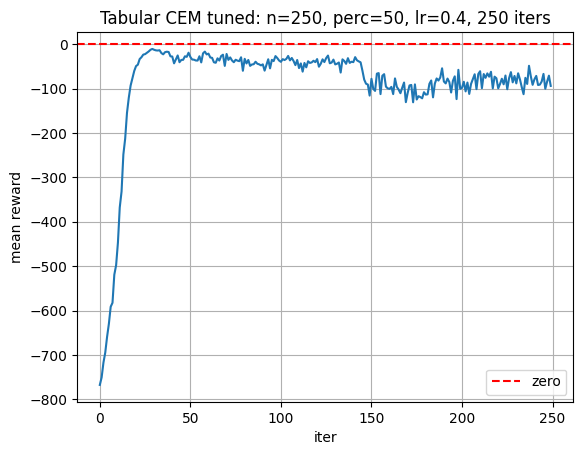

In [13]:
# --- HW PART I: tune to (near) positive mean reward on Taxi-v3 ---
np.random.seed(1)
pol = init_uniform(n_states_t, n_actions_t)
means_pos = []
for it in range(250):
    pol, mean_r = cem_iter(taxi_env, pol, n_sess=250, perc=50, lr=0.4)
    means_pos.append(mean_r)

print(f"Best window mean over training: {max(np.mean(means_pos[i:i+20]) for i in range(len(means_pos)-20)):.3f}")
print(f"Final mean reward (last 20 iters): {np.mean(means_pos[-20:]):.3f}")
plt.plot(means_pos); plt.grid(); plt.xlabel("iter"); plt.ylabel("mean reward")
plt.axhline(0, color='red', ls='--', label='zero')
plt.title("Tabular CEM tuned: n=250, perc=50, lr=0.4, 250 iters"); plt.legend(); plt.show()

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

### HW Part II — Deep CEM on LunarLander-v3

Задача 2.1: получить mean reward ≥ +50 на `LunarLander-v3`.

Что сделано:
- Сеть `MLPClassifier(hidden_layer_sizes=(128, 128), activation='tanh', warm_start=True)`.
- `n_sessions=100`, `percentile=70`, `t_max=1000`.
- **Бонус 2.2:** реализован re-use элитных эпизодов из последних 5 итераций (накапливаем `(states, actions, reward)` в `deque(maxlen=5*n_sessions)` и считаем threshold по объединённой выборке).
- Используется `reward > threshold` (а не `>=`), чтобы ранние «плохие» сессии не попадали в элиту, когда threshold проседает.

iter   0  mean=-336.98  thr=-249.09  elites_used=3113


iter   5  mean=-144.03  thr=-106.05  elites_used=15557


iter  10  mean= -81.24  thr= -75.71  elites_used=16254


iter  15  mean= -64.56  thr= -55.67  elites_used=16495


iter  20  mean= -46.86  thr= -40.15  elites_used=16998


iter  25  mean= -29.82  thr= -20.08  elites_used=19069


iter  30  mean=  -9.17  thr=  -3.27  elites_used=18024


iter  35  mean=   9.13  thr=  13.20  elites_used=21049


iter  40  mean=  20.94  thr=  27.04  elites_used=24977


iter  45  mean=  34.37  thr=  42.32  elites_used=47788


iter  50  mean=  37.82  thr=  49.22  elites_used=81329


iter  55  mean=  41.91  thr=  59.29  elites_used=118579


iter  60  mean=  46.97  thr=  65.67  elites_used=134733


== HW target reached: last-5 mean = 50.70 ==


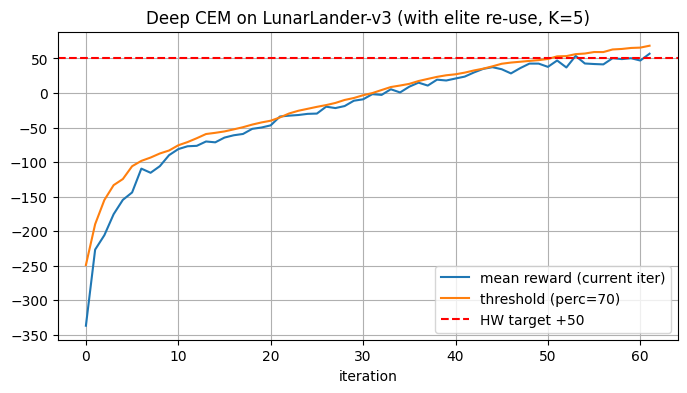

Final mean (last 5): 50.70


In [14]:
# --- HW Part II: Deep CEM on LunarLander-v3 with elite re-use ---
import gymnasium as gym
import numpy as np
from collections import deque
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

env_ll = gym.make("LunarLander-v3")
n_act_ll = env_ll.action_space.n
state_dim_ll = env_ll.observation_space.shape[0]

agent_ll = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    activation="tanh",
    warm_start=True,
    max_iter=1,
    learning_rate_init=1e-3,
)
agent_ll.partial_fit(np.zeros((n_act_ll, state_dim_ll)), np.arange(n_act_ll), classes=np.arange(n_act_ll))


def gen_session_ll(env, agent, t_max=1000):
    states, actions, total = [], [], 0.0
    s, _ = env.reset()
    for _ in range(t_max):
        probs = agent.predict_proba(s.reshape(1, -1))[0]
        a = np.random.choice(n_act_ll, p=probs)
        ns, r, term, trunc, _ = env.step(a)
        states.append(s); actions.append(a); total += r
        s = ns
        if term or trunc:
            break
    return states, actions, total


N_SESSIONS = 100
PERCENTILE = 70
N_ITERS = 120
HIST_K = 5

elite_buf_states = deque(maxlen=HIST_K)
elite_buf_actions = deque(maxlen=HIST_K)
elite_buf_rewards = deque(maxlen=HIST_K)

mean_log, thr_log = [], []
np.random.seed(2)

for it in range(N_ITERS):
    sessions = [gen_session_ll(env_ll, agent_ll) for _ in range(N_SESSIONS)]
    sb, ab, rb = zip(*sessions)
    elite_buf_states.append(sb); elite_buf_actions.append(ab); elite_buf_rewards.append(rb)

    all_s = [s for batch in elite_buf_states for s in batch]
    all_a = [a for batch in elite_buf_actions for a in batch]
    all_r = [r for batch in elite_buf_rewards for r in batch]

    thr = np.percentile(all_r, PERCENTILE)
    es, ea = [], []
    for st, ac, r in zip(all_s, all_a, all_r):
        if r > thr:
            es.extend(st); ea.extend(ac)

    if len(es) >= 2 * n_act_ll:
        Xe = np.asarray(es); ye = np.asarray(ea)
        for _ in range(5):
            agent_ll.partial_fit(Xe, ye)

    cur_mean = np.mean(rb); mean_log.append(cur_mean); thr_log.append(thr)
    if it % 5 == 0 or it == N_ITERS - 1:
        print(f"iter {it:3d}  mean={cur_mean:7.2f}  thr={thr:7.2f}  elites_used={len(es)}")
    if len(mean_log) >= 5 and np.mean(mean_log[-5:]) > 50:
        print(f"== HW target reached: last-5 mean = {np.mean(mean_log[-5:]):.2f} ==")
        break

plt.figure(figsize=(8, 4))
plt.plot(mean_log, label="mean reward (current iter)")
plt.plot(thr_log, label=f"threshold (perc={PERCENTILE})")
plt.axhline(50, color="red", linestyle="--", label="HW target +50")
plt.legend(); plt.grid(); plt.xlabel("iteration"); plt.title("Deep CEM on LunarLander-v3 (with elite re-use, K=5)")
plt.show()
print(f"Final mean (last 5): {np.mean(mean_log[-5:]):.2f}")

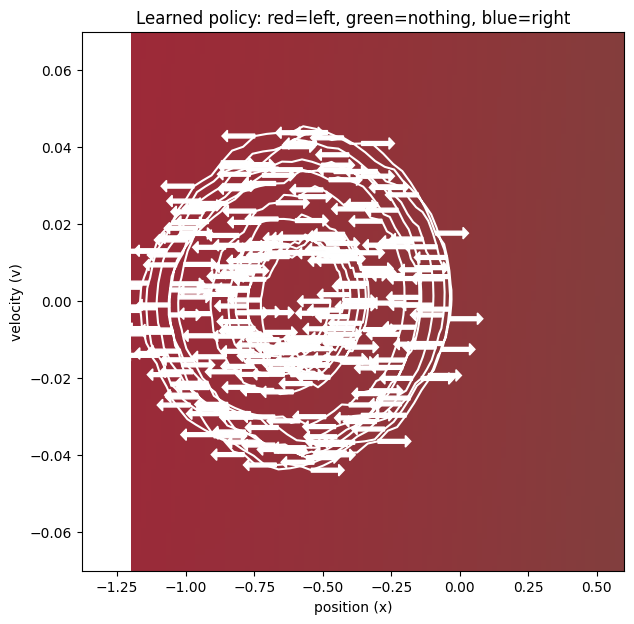

In [15]:
def visualize_mountain_car(env, agent):
    # Unwrap to access env-specific attributes (min_position, max_speed, ...)
    base = env.unwrapped
    # Compute policy for all possible x and v (with discretization)
    xs = np.linspace(base.min_position, base.max_position, 100)
    vs = np.linspace(-base.max_speed, base.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    # # The above code is equivalent to the following:
    # probs = np.empty((len(vs), len(xs), 3))
    # for i, v in enumerate(vs[::-1]):
    #     for j, x in enumerate(xs):
    #         probs[i, j, :] = agent.predict_proba([[x, v]])[0]

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(base.min_position, base.max_position, -base.max_speed, base.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample a trajectory and draw it
    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="white", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="white", head_length=0.02)


# Note: visualize_mountain_car expects an MLPClassifier with 3 actions (MountainCar).
# The CartPole `agent` from earlier cells has only 2 outputs, so we train a small MountainCar agent
# here just to demo the visualization helper (NOT the HW Part II target).
from sklearn.neural_network import MLPClassifier
mc_env = gym.make("MountainCar-v0", render_mode="rgb_array").env  # remove TimeLimit
mc_agent = MLPClassifier(hidden_layer_sizes=(32,), activation="tanh", warm_start=True, max_iter=1)
mc_agent.partial_fit(np.zeros((3, 2)), [0, 1, 2], classes=[0, 1, 2])
with mc_env as env:
    visualize_mountain_car(env, mc_agent)
plt.show()


### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.